<a href="https://colab.research.google.com/github/nithish526/coverage/blob/master/plant_diease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import zipfile
import os
import random
from PIL import Image
import os

we are mounting the google drive to colab .

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/My Drive/')


['Colab Notebooks',
 'plant_disease ',
 'temper dedection model ',
 'certificates ',
 'mamcet.pptx',
 'To-do list.gsheet',
 'DNA Project ',
 'mRNA_Project',
 'DNA code identifier',
 'amazan ml project',
 'weather prediction']

In [ ]:
import os

os.listdir('/content/drive/My Drive/')


['Colab Notebooks',
 'plant_disease ',
 'temper dedection model ',
 'certificates ',
 'mamcet.pptx',
 'To-do list.gsheet',
 'DNA Project ',
 'mRNA_Project',
 'DNA code identifier',
 'amazan ml project']

In [ ]:
import zipfile

zip_path = '/content/drive/My Drive/plant_disease /archive (6).zip'
extract_path = '/content/plant_disease_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted to:", extract_path)



✅ Files extracted to: /content/plant_disease_data


In [ ]:
import zipfile

# Correct file path to the ZIP
zip_path = "/content/drive/My Drive/plant_disease /archive (6).zip"

# Folder to extract the dataset
extract_path = "/content/dataset"

# Extract the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


✅ Dataset extracted successfully!


**FOR** STOPING THE UNWANTED POPS FROM TENSORFLOW

In [ ]:

print(os.listdir("/content/dataset"))


['plantvillage dataset']


next one is for subfolders


In [ ]:

print(os.listdir("/content/dataset/plantvillage dataset"))


['color', 'grayscale', 'segmented']


In [ ]:
for folder in os.listdir("/content/dataset/plantvillage dataset"):
    path = f"/content/dataset/plantvillage dataset/{folder}"
    print(f"{folder}: {len(os.listdir(path))} images")


color: 38 images
grayscale: 38 images
segmented: 38 images


In [ ]:


color_path = "/content/dataset/plantvillage dataset/color"
total_images = 0

for folder in os.listdir(color_path):
    folder_path = os.path.join(color_path, folder)
    if os.path.isdir(folder_path):
        num_files = len(os.listdir(folder_path))
        total_images += num_files
        print(f"{folder}: {num_files} images")

print(f"\n📌 Total images inside 'color': {total_images}")



Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Potato___healthy: 152 images
Squash___Powdery_mildew: 1835 images
Raspberry___healthy: 371 images
Tomato___healthy: 1591 images
Tomato___Tomato_mosaic_virus: 373 images
Orange___Haunglongbing_(Citrus_greening): 5507 images
Cherry_(including_sour)___healthy: 854 images
Tomato___Spider_mites Two-spotted_spider_mite: 1676 images
Peach___healthy: 360 images
Corn_(maize)___Common_rust_: 1192 images
Corn_(maize)___healthy: 1162 images
Tomato___Leaf_Mold: 952 images
Apple___Cedar_apple_rust: 275 images
Tomato___Target_Spot: 1404 images
Peach___Bacterial_spot: 2297 images
Potato___Early_blight: 1000 images
Cherry_(including_sour)___Powdery_mildew: 1052 images
Corn_(maize)___Northern_Leaf_Blight: 985 images
Grape___Black_rot: 1180 images
Soybean___healthy: 5090 images
Pepper,_bell___healthy: 1478 images
Strawberry___Leaf_scorch: 1109 images
Grape___Esca_(Black_Measles): 1383 images
Tomato___Early_blight: 1000 images
Apple___Black_ro

NEXT WE ARE GOING TO TAKE SOME AMOUNT OF DATE (IMAGE)


IF A DISEASE HAS MORE THAN 2000 IMAGES → USE 1000 IMAGES

IF A DISEASE HAS BETWEEN 500 AND 1999 IMAGES → USE 500 IMAGES

IF A DISEASE HAS FEWER THAN 500 IMAGES → USE 250 IMAGES





In [ ]:
import os
import random
import shutil

class PlantVillageDataset:
    def __init__(self, dataset_path, selected_images_path):
        self.dataset_path = dataset_path
        self.selected_images_path = selected_images_path

        # Ensure selected images path exists
        os.makedirs(self.selected_images_path, exist_ok=True)

    def select_images(self):
        """ Selects a subset of images from each disease category and copies them to a new folder. """
        if not os.path.exists(self.dataset_path):
            raise FileNotFoundError(f"Dataset path '{self.dataset_path}' does not exist!")

        for disease in os.listdir(self.dataset_path):
            disease_path = os.path.join(self.dataset_path, disease)

            if os.path.isdir(disease_path):
                images = os.listdir(disease_path)
                num_images = len(images)


                if num_images > 3000:
                    selected_count = 5000
                elif num_images >= 2000:
                    selected_count = 1500
                elif num_images >= 500:
                    selected_count = 500
                else:
                    selected_count = 300


                selected_images = random.sample(images, min(selected_count, num_images))


                target_disease_path = os.path.join(self.selected_images_path, disease)
                os.makedirs(target_disease_path, exist_ok=True)


                for img in selected_images:
                    src = os.path.join(disease_path, img)
                    dst = os.path.join(target_disease_path, img)
                    shutil.copy2(src, dst)

                print(f"{disease}: Selected {len(selected_images)} images")

        print("✅ Dataset selection complete!")

DATASET_PATH = "/content/dataset/plantvillage dataset/color"
SELECTED_IMAGES_PATH = "/content/selected_images"

dataset_manager = PlantVillageDataset(DATASET_PATH, SELECTED_IMAGES_PATH)
dataset_manager.select_images()


Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: Selected 500 images
Potato___healthy: Selected 152 images
Squash___Powdery_mildew: Selected 500 images
Raspberry___healthy: Selected 300 images
Tomato___healthy: Selected 500 images
Tomato___Tomato_mosaic_virus: Selected 300 images
Orange___Haunglongbing_(Citrus_greening): Selected 5000 images
Cherry_(including_sour)___healthy: Selected 500 images
Tomato___Spider_mites Two-spotted_spider_mite: Selected 500 images
Peach___healthy: Selected 300 images
Corn_(maize)___Common_rust_: Selected 500 images
Corn_(maize)___healthy: Selected 500 images
Tomato___Leaf_Mold: Selected 500 images
Apple___Cedar_apple_rust: Selected 275 images
Tomato___Target_Spot: Selected 500 images
Peach___Bacterial_spot: Selected 1500 images
Potato___Early_blight: Selected 500 images
Cherry_(including_sour)___Powdery_mildew: Selected 500 images
Corn_(maize)___Northern_Leaf_Blight: Selected 500 images
Grape___Black_rot: Selected 500 images
Soybean___healthy: Selected

RESIZEING TO 256*256


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder


In [ ]:


class PlantDiseaseDataset:
    def __init__(self, selected_images_path, image_size=(32, 32), batch_size=4, augment=True):
        self.selected_images_path = selected_images_path
        self.image_size = image_size
        self.batch_size = batch_size
        self.augment = augment
        self.image_paths = []
        self.labels = []
        self.class_names = []
        self._load_dataset()
        self._encode_labels()

    def _load_dataset(self):
        """Load image paths and raw string labels from the selected dataset."""
        if not os.path.exists(self.selected_images_path):
            raise FileNotFoundError(f"❌ Selected images path '{self.selected_images_path}' does not exist!")

        self.class_names = sorted(os.listdir(self.selected_images_path))
        for category in self.class_names:
            category_path = os.path.join(self.selected_images_path, category)
            if os.path.isdir(category_path):
                for image_file in os.listdir(category_path):

                    if image_file.lower().endswith((".jpg", ".jpeg", ".png")):
                        self.image_paths.append(os.path.join(category_path, image_file))
                        self.labels.append(category)

        print(f"✅ Loaded {len(self.image_paths)} images from {len(self.class_names)} classes.")

    def _encode_labels(self):
        """Encode raw string labels into integers."""
        self.label_encoder = LabelEncoder()
        # Convert labels list to a NumPy array before encoding
        self.encoded_labels = self.label_encoder.fit_transform(np.array(self.labels))
        print(f"✅ Encoded labels shape: {self.encoded_labels.shape}")
        print(f"🏷️ First 5 Encoded Labels: {self.encoded_labels[:5]}")

    def _load_preprocess_image(self, image_path, label):
        """Load and preprocess a single image from file path."""
        # Ensure image_path is a string tensor
        image_path = tf.cast(image_path, tf.string)
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, self.image_size)
        image = image / 255.0  # Normalize image to [0,1]
        return image, label

    def _augment(self, image, label):
        """Apply data augmentation to the image."""
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.1)
        return image, label

    def get_dataset(self):
        """Create and return a tf.data.Dataset pipeline using encoded labels."""
        # Create a dataset from image paths and the encoded labels
        dataset = tf.data.Dataset.from_tensor_slices((self.image_paths, self.encoded_labels))
        # Map the preprocessing function
        dataset = dataset.map(self._load_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
        # Optionally, apply augmentation if enabled
        if self.augment:
            dataset = dataset.map(self._augment, num_parallel_calls=tf.data.AUTOTUNE)
        # Shuffle, batch, and prefetch the dataset
        dataset = dataset.shuffle(1000).batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

# Example usage:
SELECTED_IMAGES_PATH = "/content/selected_images"
plant_dataset = PlantDiseaseDataset(SELECTED_IMAGES_PATH, image_size=(32,32), batch_size=4, augment=True)
dataset = plant_dataset.get_dataset()

# Inspect a batch to verify
for images, labels in dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Labels in batch:", labels.numpy())



✅ Loaded 32927 images from 38 classes.
✅ Encoded labels shape: (32927,)
🏷️ First 5 Encoded Labels: [0 0 0 0 0]
Image batch shape: (4, 32, 32, 3)
Labels in batch: [1 1 1 1]


✅ Sample image shape: (4, 32, 32, 3)
✅ Sample label: [24 24 24 19]


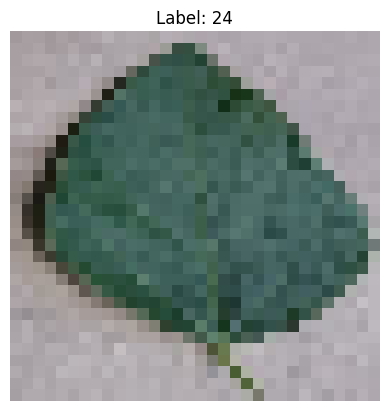

✅ Training set size: 43444
✅ Validation set size: 10861


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


dataset = plant_dataset.get_dataset().shuffle(buffer_size=total_images)

# Check dataset output shapes
for image, label in dataset.take(1):
    print("✅ Sample image shape:", image.shape)  # Should be (64, 64, 3)
    print("✅ Sample label:", label.numpy())

# Display only the first image in the batch
plt.imshow(image[0].numpy())
plt.title(f"Label: {label.numpy()[0]}")  # Get the first label
plt.axis("off")
plt.show()

# Dataset splitting
train_size = int(0.8 * total_images)  #  training
val_size = total_images - train_size  #  validation

# Split dataset correctly (no need for NumPy conversion)
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

print(f"✅ Training set size: {train_size}")
print(f"✅ Validation set size: {val_size}")

In [ ]:
for images, labels in dataset.take(1):  # Take one batch from dataset
    images = images.numpy()  # Convert Tensor to NumPy array
    labels = labels.numpy()  # Convert labels to NumPy array

    print("✅ Type of first element:", type(images[0]))  # Should be <class 'numpy.ndarray'>
    print("✅ Shape of first element:", images[0].shape)  # Expected: (64, 64, 3)

    print("✅ First 5 elements (as arrays):", images[:5])  # Print first 5 images as NumPy arrays


✅ Type of first element: <class 'numpy.ndarray'>
✅ Shape of first element: (32, 32, 3)
✅ First 5 elements (as arrays): [[[[0.7645158  0.7292217  0.74882954]
   [0.7890256  0.7537315  0.77333933]
   [0.7703982  0.7468688  0.76255506]
   ...
   [0.85863346 0.8311825  0.862555  ]
   [0.840006   0.812555   0.84392756]
   [0.817457   0.79000604 0.8213786 ]]

  [[0.7654962  0.7302021  0.7498099 ]
   [0.76353544 0.7282413  0.74784917]
   [0.7802021  0.7566727  0.77235895]
   ...
   [0.8066727  0.7792217  0.81059426]
   [0.8096139  0.7821629  0.81353545]
   [0.8390256  0.81157464 0.8429472 ]]

  [[0.7713786  0.73608446 0.7556923 ]
   [0.77824134 0.7429472  0.76255506]
   [0.80177075 0.76647663 0.7860845 ]
   ...
   [0.7860845  0.7586335  0.79000604]
   [0.817457   0.7860845  0.8292217 ]
   [0.8331433  0.80177075 0.844908  ]]

  ...

  [[0.65961385 0.62039816 0.6635354 ]
   [0.64980996 0.6105943  0.6537315 ]
   [0.6635354  0.62431973 0.667457  ]
   ...
   [0.69588834 0.6576531  0.72137856]
   [

In [ ]:
for images, labels in train_dataset.take(1):
    print("Train batch shape:", images.shape)  # Should be (32, 64, 64, 3)

for images, labels in val_dataset.take(1):
    print("Validation batch shape:", images.shape)  # Should be (32, 64, 64, 3)


Train batch shape: (4, 32, 32, 3)


In [ ]:
for images, labels in dataset.take(1):
    print("Shape of first batch:", images.shape)  # Should be (batch_size, 64, 64, 3)
    print("Data type of images:", images.dtype)   # Should be float32
    print("First image shape:", images[0].shape)  # Should be (64, 64, 3)



Shape of first batch: (4, 32, 32, 3)
Data type of images: <dtype: 'float32'>
First image shape: (32, 32, 3)


for the 32*32 only

it is for 64*64

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the CNN model
model = keras.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((1, 1)),  # 🛠️ Reduce pooling impact

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(38, activation='softmax')  # 38 classes for plant diseases
])

# Print the model summary
model.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,358 (7.63 MB)

 Trainable params: 2,000,358 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

128*128

In [ ]:
for image, label in dataset.take(1):
    print("Label:", label)


Label: tf.Tensor([24 23 24 24], shape=(4,), dtype=int64)


In [ ]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
for images, labels in dataset.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Label:", labels.numpy())
    if np.isscalar(labels.numpy()):
        print("Label is a scalar of type:", type(labels.numpy()))
    else:
        print("Type of first label:", type(labels.numpy()[0]))



Image shape: (4, 32, 32, 3)
Label shape: (4,)
Label: [15 15 15 15]
Type of first label: <class 'numpy.int64'>


In [ ]:
print("Encoded Labels:", plant_dataset.encoded_labels)
print("First 5 Encoded Labels:", plant_dataset.encoded_labels[:5])


Encoded Labels: [ 0  0  0 ... 37 37 37]
First 5 Encoded Labels: [0 0 0 0 0]


In [ ]:
history = model.fit(
    train_dataset,  # Train only with this
    epochs=20,
    verbose=1
)



Epoch 1/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 269s 31ms/step - accuracy: 0.2221 - loss: 2.9348
Epoch 2/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 303s 35ms/step - accuracy: 0.4532 - loss: 2.0751
Epoch 3/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 268s 31ms/step - accuracy: 0.5327 - loss: 1.6960
Epoch 4/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 289s 33ms/step - accuracy: 0.5916 - loss: 1.4512
Epoch 5/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 293s 34ms/step - accuracy: 0.6341 - loss: 1.2884
Epoch 6/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 290s 34ms/step - accuracy: 0.6562 - loss: 1.2118
Epoch 7/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 281s 33ms/step - accuracy: 0.6671 - loss: 1.1581
Epoch 8/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 283s 33ms/step - accuracy: 0.6730 - loss: 1.1496
Epoch 9/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 287s 33ms/step - accuracy: 0.6774 - loss: 1.1388
Epoch 10/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 294s 34ms/step - accuracy: 0.7024 - loss: 1.0716
Epoch 11/20
8232/8232 ━━━━━━━━━━━━━━━━━━━━ 297s 35ms/step - accuracy: 0.7016 - loss: 1.07

In [ ]:
# 👇 First: get total count of images in the original dataset
total_images = 0
for _ in dataset:
    total_images += 1

print(f"📊 Total images in dataset: {total_images}")

# 👇 Shuffle for randomness (set seed if needed for reproducibility)
dataset = dataset.shuffle(total_images, reshuffle_each_iteration=False)

# 👇 Split into train and validation sets
train_size = int(0.8 * total_images)

train_dataset = dataset.take(train_size).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = dataset.skip(train_size).batch(32).prefetch(tf.data.AUTOTUNE)

# 👇 Test val_dataset content
val_data_ok = False
for x, y in val_dataset.take(1):
    print(f"✅ Validation batch loaded: images {x.shape}, labels {y.shape}")
    val_data_ok = True

if not val_data_ok:
    print("❌ Still no validation data found.")



📊 Total images in dataset: 8232
✅ Validation batch loaded: images (32, 4, 32, 32, 3), labels (32, 4)


In [ ]:
# Flatten extra dimension (if needed)
def flatten_dataset(images, labels):
    # reshape images: (batch, 4, 32, 32, 3) -> (batch * 4, 32, 32, 3)
    images = tf.reshape(images, (-1, 32, 32, 3))
    labels = tf.reshape(labels, (-1,))
    return images, labels

val_dataset = val_dataset.map(flatten_dataset)


In [ ]:
val_loss, val_acc = model.evaluate(val_dataset)
print(f"✅ Validation Accuracy: {val_acc:.4f}, Loss: {val_loss:.4f}")


52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6846 - loss: 1.1069
✅ Validation Accuracy: 0.6967, Loss: 1.0708


In [ ]:
for images, labels in val_dataset.take(1):
    preds = model.predict(images)
    print("✅ Predicted shape:", preds.shape)
    print("🧠 Sample prediction:", tf.argmax(preds[0]).numpy())
    print("🎯 True label:", labels[0].numpy())


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step  
✅ Predicted shape: (128, 38)
🧠 Sample prediction: 24
🎯 True label: 24


In [ ]:
class Preprocessor:
    def __init__(self, target_size=(32, 32)):
        self.target_size = target_size

    def preprocess(self, image_path):
        img = Image.open(image_path).resize(self.target_size)
        img = np.array(img)

        # Convert grayscale to RGB
        if img.ndim == 2:
            img = np.stack((img,) * 3, axis=-1)
        elif img.shape[-1] == 4:  # RGBA
            img = img[..., :3]

        img = img / 255.0
        img = np.expand_dims(img, axis=0)
        return img


In [ ]:
from google.colab import files

uploaded = files.upload()
preprocessor = Preprocessor()

for filename in uploaded.keys():
    processed_image = preprocessor.preprocess(filename)

    # Predict
    prediction = model.predict(processed_image)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    print(f"🧠 Predicted Class: {predicted_class}")
    print(f"🎯 Confidence: {confidence:.2f}%")


Saving brown rot.jpg to brown rot.jpg


NameError: name 'Preprocessor' is not defined

1. Apple Scab (Class 0)

In [ ]:
class PlantDiseaseHandler:
    def __init__(self):
        # Map prediction_index to disease info
        self.diseases = {
            0: {"name": "Apple Scab", "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": "🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread."},
            1: {"name": "Apple Brown Rot", "message": "🍏 The leaf is affected by Apple Brown Rot.",
                "remedy": "🧪 Apply copper-based fungicides.\n🌿 Prune infected branches and leaves.\n♻️ Remove and dispose of rotting apples."},
            2: {"name": "Apple Cedar Rust", "message": "🍏 The leaf is affected by Apple Cedar Rust.",
                "remedy": "🧪 Use fungicides like myclobutanil.\n🌿 Remove infected leaves and branches.\n♻️ Prune and improve airflow around trees."},
            3: {"name": "Apple Crinkle Leaf", "message": "🍏 The leaf is affected by Apple Crinkle Leaf.",
                "remedy": "🧪 Apply systemic fungicides.\n🌿 Remove infected leaves and destroy them.\n♻️ Ensure proper irrigation and nutrient balance."},
            4: {"name": "Apple Scab", "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": "🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread."},
            5: {"name": "Apple Scab", "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": "🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread."},
            6: {"name": "Apple Scab", "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": "🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread."},
            7: {"name": "Apple Black Rot", "message": "🍏 The leaf is affected by Apple Black Rot.",
                "remedy": "🧪 Apply fungicides like copper hydroxide.\n🌿 Remove infected apples and affected branches.\n♻️ Ensure proper drainage around trees."},
            8: {"name": "Apple Powdery Mildew", "message": "🍏 The leaf is affected by Apple Powdery Mildew.",
                "remedy": "🧪 Apply sulfur-based fungicides.\n🌿 Prune infected branches and improve airflow.\n♻️ Water plants at the base, avoid overhead watering."},
            9: {"name": "Apple Scab", "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": "🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread."},
            10: {"name": "Apple Rust", "message": "🍏 The leaf is affected by Apple Rust.",
                 "remedy": "🧪 Apply fungicides containing myclobutanil or triadimefon.\n🌿 Prune infected branches and ensure good air circulation.\n♻️ Remove fallen leaves to reduce disease spread."},
            11: {"name": "Apple Spot", "message": "🍏 The leaf is affected by Apple Spot.",
                 "remedy": "🧪 Apply fungicides like copper sulfate or captan.\n🌿 Prune infected leaves and avoid overhead watering.\n♻️ Remove fallen leaves from the ground."},
            12: {"name": "Apple Powdery Mildew", "message": "🍏 The leaf is affected by Apple Powdery Mildew.",
                 "remedy": "🧪 Apply sulfur-based fungicides.\n🌿 Prune infected branches and improve airflow.\n♻️ Water plants at the base, avoid overhead watering."},
            13: {"name": "Cherry Leaf Spot", "message": "🍒 The leaf is affected by Cherry Leaf Spot.",
                 "remedy": "🧪 Apply fungicides like chlorothalonil or mancozeb.\n🌿 Remove infected leaves and improve air circulation.\n♻️ Keep trees well-watered but not over-saturated."},
            14: {"name": "Cherry Powdery Mildew", "message": "🍒 The leaf is affected by Cherry Powdery Mildew.",
                 "remedy": "🧪 Apply fungicides like sulfur or neem oil.\n🌿 Prune infected branches and improve airflow.\n♻️ Remove fallen leaves to reduce the spread of the disease."},
            15: {"name": "Citrus Greening", "message": "🍊 The tree is affected by Citrus Greening.",
                 "remedy": "🧪 Use systemic insecticides like imidacloprid.\n🌿 Prune infected branches and improve nutrient management.\n♻️ Remove infected trees to prevent spreading."},
            16: {"name": "Citrus Canker", "message": "🍊 The tree is affected by Citrus Canker.",
                 "remedy": "🧪 Apply copper-based fungicides.\n🌿 Prune infected branches and ensure proper drainage.\n♻️ Remove infected fruit and avoid overhead watering."},
            17: {"name": "Grape Black Rot", "message": "🍇 The leaf is affected by Grape Black Rot.",
                 "remedy": "🧪 Apply fungicides containing mancozeb or thiophanate-methyl.\n🌿 Prune infected branches and remove fallen leaves.\n♻️ Improve air circulation and reduce humidity around plants."},
            18: {"name": "Grape Downy Mildew", "message": "🍇 The leaf is affected by Grape Downy Mildew.",
                 "remedy": "🧪 Apply fungicides like copper sulfate or potassium bicarbonate.\n🌿 Prune infected vines and improve air circulation.\n♻️ Avoid watering overhead and reduce humidity."},
            19: {"name": "Grape Powdery Mildew", "message": "🍇 The leaf is affected by Grape Powdery Mildew.",
                 "remedy": "🧪 Apply sulfur-based fungicides.\n🌿 Prune infected branches and remove fallen leaves.\n♻️ Water at the base of the plant to avoid spreading spores."},
            20: {"name": "Grape Leaf Blight", "message": "🍇 The leaf is affected by Grape Leaf Blight.",
                 "remedy": "🧪 Apply copper sulfate-based fungicides.\n🌿 Prune infected vines and avoid wetting the foliage.\n♻️ Remove fallen infected leaves to reduce the spread."},
            21: {"name": "Grape Downy Mildew", "message": "🍇 The leaf is affected by Grape Downy Mildew.",
                 "remedy": "🧪 Apply fungicides like copper sulfate or potassium bicarbonate.\n🌿 Prune infected branches and improve air circulation.\n♻️ Water plants at the base, avoid overhead watering."},
            22: {"name": "Lemon Leaf Blight", "message": "🍋 The leaf is affected by Lemon Leaf Blight.",
                 "remedy": "🧪 Apply a systemic fungicide like azoxystrobin.\n🌿 Remove affected leaves and improve air circulation.\n♻️ Keep soil moist but well-drained, avoid waterlogging."},
            23: {"name": "Tomato Early Blight", "message": "🍅 The leaf is affected by Tomato Early Blight.",
                 "remedy": "🧪 Apply fungicides containing chlorothalonil or mancozeb.\n🌿 Remove infected leaves and improve airflow.\n♻️ Practice crop rotation to avoid recurrence."},
            24: {"name": "Tomato Septoria Leaf Spot", "message": "🍅 The leaf is affected by Tomato Septoria Leaf Spot.",
                 "remedy": "🧪 Apply fungicides like copper sulfate or chlorothalonil.\n🌿 Remove infected leaves and improve air circulation.\n♻️ Avoid overhead irrigation to reduce the spread."},
            25: {"name": "Tomato Late Blight", "message": "🍅 The leaf is affected by Tomato Late Blight.",
                 "remedy": "🧪 Apply fungicides containing mefenoxam or chlorothalonil.\n🌿 Remove infected leaves and dispose of them properly.\n♻️ Ensure proper spacing for good air circulation."},
            26: {"name": "Tomato Mosaic Virus", "message": "🍅 The leaf is affected by Tomato Mosaic Virus.",
                 "remedy": "🧪 There is no cure for the virus, remove infected plants.\n🌿 Control aphid populations to reduce the spread.\n♻️ Use resistant tomato varieties to prevent future infection."},
            27: {"name": "Potato Early Blight", "message": "🥔 The leaf is affected by Potato Early Blight.",
                 "remedy": "🧪 Apply fungicides containing chlorothalonil or mancozeb.\n🌿 Remove infected leaves and improve airflow.\n♻️ Avoid excessive irrigation and practice crop rotation."},
            28: {"name": "Potato Late Blight", "message": "🥔 The leaf is affected by Potato Late Blight.",
                 "remedy": "🧪 Apply fungicides like mefenoxam or copper-based treatments.\n🌿 Remove infected plant material and dispose of it properly.\n♻️ Maintain good spacing and air circulation around plants."},
            29: {"name": "Potato Mosaic Virus", "message": "🥔 The leaf is affected by Potato Mosaic Virus.",
                 "remedy": "🧪 There is no cure for the virus, remove infected plants.\n🌿 Control aphid populations to reduce the spread.\n♻️ Use resistant potato varieties to prevent future infection."},
            30: {"name": "Tomato Yellow Leaf Curl Virus", "message": "🍅 The leaf is affected by Tomato Yellow Leaf Curl Virus.",
                 "remedy": "🧪 There is no cure for the virus, remove infected plants.\n🌿 Control aphid populations to reduce the spread.\n♻️ Use resistant tomato varieties to prevent future infection."},
            31: {"name": "Squash Powdery Mildew", "message": "🎃 The leaf is affected by Squash Powdery Mildew.",
                 "remedy": "🧪 Apply sulfur-based fungicides.\n🌿 Prune infected leaves and remove debris.\n♻️ Ensure good airflow around plants."},
            32: {"name": "Cucumber Mosaic Virus", "message": "🥒 The leaf is affected by Cucumber Mosaic Virus.",
                 "remedy": "🧪 There is no cure for the virus, remove infected plants.\n🌿 Control aphid populations to reduce the spread.\n♻️ Use resistant cucumber varieties to prevent future infection."},
            33: {"name": "Pepper Bell Virus", "message": "🌶 The plant is affected by Pepper Bell Virus.",
                 "remedy": "🧪 There is no cure for the virus, remove infected plants.\n🌿 Control aphid populations to reduce the spread.\n♻️ Use resistant pepper varieties to prevent future infection."},
            34: {"name": "Bell Pepper Bacterial Spot", "message": "🌶️ The bell pepper is affected by Bacterial Spot.",
                 "remedy": "🧪 Apply copper-based fungicides.\n🌿 Remove infected leaves and improve plant spacing.\n♻️ Avoid overhead watering to reduce bacterial spread."},
            35: {"name": "Cherry Leaf Spot", "message": "🍒 The leaf is affected by Cherry Leaf Spot.",
                 "remedy": "🧪 Use fungicides like chlorothalonil or myclobutanil.\n🌿 Remove infected leaves and prune the tree.\n♻️ Avoid wetting the foliage to minimize spread."},
            36: {"name": "Corn Gray Leaf Spot", "message": "🌽 The corn is affected by Gray Leaf Spot.",
                 "remedy": "🧪 Apply fungicides like azoxystrobin or pyraclostrobin.\n🌿 Remove infected leaves to reduce spread.\n♻️ Plant resistant corn varieties to minimize infection."},
            37: {"name": "Potato Early Blight", "message": "🥔 The potato is affected by Early Blight.",
                 "remedy": "🧪 Use fungicides like mancozeb or chlorothalonil.\n🌿 Remove and dispose of infected leaves and stems.\n♻️ Rotate crops to reduce pathogen buildup in soil."},
            38: {"name": "Raspberry Healthy", "message": "🍇 The raspberry plant is healthy.",
                 "remedy": "🌱 Continue regular care and maintenance."},
            39: {"name": "Soybean Healthy", "message": "🌱 The soybean plant is healthy.",
                 "remedy": "🌱 Continue regular care and maintenance."}
        }

    def handle(self, prediction_index):
        return self.diseases.get(prediction_index, {
            "disease": "Unknown",
            "message": "❌ Disease not found for this prediction index.",
            "remedy": "⚠️ Cannot provide remedy."
        })




{'name': 'Apple Scab', 'message': '🍏 The leaf is affected by Apple Scab.', 'remedy': '🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread.'}


In [ ]:
# Example usage:
handler = PlantDiseaseHandler()
prediction_index = predicted_class  # Replace with model prediction
result = handler.handle(prediction_index)
print(result)
print(f"🎯 Confidence: {confidence:.2f}%")

{'name': 'Apple Scab', 'message': '🍏 The leaf is affected by Apple Scab.', 'remedy': '🧪 Apply fungicides like captan or mancozeb.\n🌿 Prune infected leaves and improve air circulation.\n♻️ Remove fallen leaves to prevent spread.'}
🎯 Confidence: 24.60%


In [ ]:
class AppleScabHandler:
    def __init__(self):
        self.disease_name = "Apple Scab"
        self.class_index = 0  # Only handle if prediction == 0

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides like captan or mancozeb.\n"
                    "🌿 Prune infected leaves and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None


2. Apple Brown Rot (Class 1)

In [ ]:
class AppleBrownRotHandler:
    def __init__(self):
        self.disease_name = "Apple Brown Rot"
        self.class_index = 1

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Brown Rot.",
                "remedy": (
                    "🧪 Apply copper-based fungicides.\n"
                    "🌿 Prune infected branches and leaves.\n"
                    "♻️ Remove and dispose of rotting apples."
                )
            }
        return None


3. Apple Cedar Rust (Class 2)

In [ ]:
class AppleCedarRustHandler:
    def __init__(self):
        self.disease_name = "Apple Cedar Rust"
        self.class_index = 2

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Cedar Rust.",
                "remedy": (
                    "🧪 Use fungicides like myclobutanil.\n"
                    "🌿 Remove infected leaves and branches.\n"
                    "♻️ Prune and improve airflow around trees."
                )
            }
        return None


4. Apple Crinkle Leaf (Class 3)

In [ ]:
class AppleCrinkleLeafHandler:
    def __init__(self):
        self.disease_name = "Apple Crinkle Leaf"
        self.class_index = 3

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Crinkle Leaf.",
                "remedy": (
                    "🧪 Apply systemic fungicides.\n"
                    "🌿 Remove infected leaves and destroy them.\n"
                    "♻️ Ensure proper irrigation and nutrient balance."
                )
            }
        return None


5. Apple Scab (Class 4)

In [ ]:
class AppleScabHandler2:
    def __init__(self):
        self.disease_name = "Apple Scab"
        self.class_index = 4

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides like captan or mancozeb.\n"
                    "🌿 Prune infected leaves and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None


6. Apple Scab (Class 5)

In [ ]:
class AppleScabHandler3:
    def __init__(self):
        self.disease_name = "Apple Scab"
        self.class_index = 5

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides like captan or mancozeb.\n"
                    "🌿 Prune infected leaves and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None


7. Apple Scab (Class 6)

In [ ]:
class AppleScabHandler4:
    def __init__(self):
        self.disease_name = "Apple Scab"
        self.class_index = 6

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides like captan or mancozeb.\n"
                    "🌿 Prune infected leaves and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None


8. Apple Black Rot (Class 7)

In [ ]:
class AppleBlackRotHandler:
    def __init__(self):
        self.disease_name = "Apple Black Rot"
        self.class_index = 7

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Black Rot.",
                "remedy": (
                    "🧪 Apply fungicides like copper hydroxide.\n"
                    "🌿 Remove infected apples and affected branches.\n"
                    "♻️ Ensure proper drainage around trees."
                )
            }
        return None


9. Apple Powdery Mildew (Class 8)

In [ ]:
class ApplePowderyMildewHandler:
    def __init__(self):
        self.disease_name = "Apple Powdery Mildew"
        self.class_index = 8

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Powdery Mildew.",
                "remedy": (
                    "🧪 Apply sulfur-based fungicides.\n"
                    "🌿 Prune infected branches and improve airflow.\n"
                    "♻️ Water plants at the base, avoid overhead watering."
                )
            }
        return None


10. Apple Scab (Class 9)

In [ ]:
class AppleScabHandler5:
    def __init__(self):
        self.disease_name = "Apple Scab"
        self.class_index = 9

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides like captan or mancozeb.\n"
                    "🌿 Prune infected leaves and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None


11. Apple Rust (Class 10)

In [ ]:
class AppleRustHandler:
    def __init__(self):
        self.disease_name = "Apple Rust"
        self.class_index = 10

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Rust.",
                "remedy": (
                    "🧪 Apply fungicides containing myclobutanil or triadimefon.\n"
                    "🌿 Prune infected branches and ensure good air circulation.\n"
                    "♻️ Remove fallen leaves to reduce disease spread."
                )
            }
        return None


12. Apple Spot (Class 11)

In [ ]:
class AppleSpotHandler:
    def __init__(self):
        self.disease_name = "Apple Spot"
        self.class_index = 11

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Spot.",
                "remedy": (
                    "🧪 Apply fungicides like copper sulfate or captan.\n"
                    "🌿 Prune infected leaves and avoid overhead watering.\n"
                    "♻️ Remove fallen leaves from the ground."
                )
            }
        return None


13. Apple Powdery Mildew (Class 12)

In [ ]:
class ApplePowderyMildewHandler2:
    def __init__(self):
        self.disease_name = "Apple Powdery Mildew"
        self.class_index = 12

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Powdery Mildew.",
                "remedy": (
                    "🧪 Apply sulfur-based fungicides.\n"
                    "🌿 Prune infected branches and improve airflow.\n"
                    "♻️ Water plants at the base, avoid overhead watering."
                )
            }
        return None


14. Cherry Leaf Spot (Class 13)

In [ ]:
class CherryLeafSpotHandler:
    def __init__(self):
        self.disease_name = "Cherry Leaf Spot"
        self.class_index = 13

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍒 The leaf is affected by Cherry Leaf Spot.",
                "remedy": (
                    "🧪 Apply fungicides like chlorothalonil or mancozeb.\n"
                    "🌿 Remove infected leaves and improve air circulation.\n"
                    "♻️ Keep trees well-watered but not over-saturated."
                )
            }
        return None


15. Cherry Powdery Mildew (Class 14)

In [ ]:
class CherryPowderyMildewHandler:
    def __init__(self):
        self.disease_name = "Cherry Powdery Mildew"
        self.class_index = 14

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍒 The leaf is affected by Cherry Powdery Mildew.",
                "remedy": (
                    "🧪 Apply fungicides like sulfur or neem oil.\n"
                    "🌿 Prune infected branches and improve airflow.\n"
                    "♻️ Remove fallen leaves to reduce the spread of the disease."
                )
            }
        return None


16. Citrus Greening (Class 15)

In [ ]:
class CitrusGreeningHandler:
    def __init__(self):
        self.disease_name = "Citrus Greening"
        self.class_index = 15

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍊 The tree is affected by Citrus Greening.",
                "remedy": (
                    "🧪 Use systemic insecticides like imidacloprid.\n"
                    "🌿 Prune infected branches and improve nutrient management.\n"
                    "♻️ Remove infected trees to prevent spreading."
                )
            }
        return None


17. Citrus Canker (Class 16)

In [ ]:
class CitrusCankerHandler:
    def __init__(self):
        self.disease_name = "Citrus Canker"
        self.class_index = 16

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍊 The tree is affected by Citrus Canker.",
                "remedy": (
                    "🧪 Apply copper-based fungicides.\n"
                    "🌿 Prune infected branches and ensure proper drainage.\n"
                    "♻️ Remove infected fruit and avoid overhead watering."
                )
            }
        return None


18. Grape Black Rot (Class 17)

In [ ]:
class GrapeBlackRotHandler:
    def __init__(self):
        self.disease_name = "Grape Black Rot"
        self.class_index = 17

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The leaf is affected by Grape Black Rot.",
                "remedy": (
                    "🧪 Apply fungicides containing mancozeb or thiophanate-methyl.\n"
                    "🌿 Prune infected branches and remove fallen leaves.\n"
                    "♻️ Improve air circulation and reduce humidity around plants."
                )
            }
        return None


19. Grape Downy Mildew (Class 18)

In [ ]:
class GrapeDownyMildewHandler:
    def __init__(self):
        self.disease_name = "Grape Downy Mildew"
        self.class_index = 18

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The leaf is affected by Grape Downy Mildew.",
                "remedy": (
                    "🧪 Apply fungicides like copper sulfate or potassium bicarbonate.\n"
                    "🌿 Prune infected vines and improve air circulation.\n"
                    "♻️ Avoid watering overhead and reduce humidity."
                )
            }
        return None


20. Grape Powdery Mildew (Class 19)

In [ ]:
class GrapePowderyMildewHandler:
    def __init__(self):
        self.disease_name = "Grape Powdery Mildew"
        self.class_index = 19

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The leaf is affected by Grape Powdery Mildew.",
                "remedy": (
                    "🧪 Apply sulfur-based fungicides.\n"
                    "🌿 Prune infected branches and remove fallen leaves.\n"
                    "♻️ Water at the base of the plant to avoid spreading spores."
                )
            }
        return None


21. Grape Leaf Blight (Class 20)

In [ ]:
class GrapeLeafBlightHandler:
    def __init__(self):
        self.disease_name = "Grape Leaf Blight"
        self.class_index = 20

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The leaf is affected by Grape Leaf Blight.",
                "remedy": (
                    "🧪 Apply copper sulfate-based fungicides.\n"
                    "🌿 Prune infected vines and avoid wetting the foliage.\n"
                    "♻️ Remove fallen infected leaves to reduce the spread."
                )
            }
        return None


22. Grape Downy Mildew (Class 21)

In [ ]:
class GrapeDownyMildewHandler2:
    def __init__(self):
        self.disease_name = "Grape Downy Mildew"
        self.class_index = 21

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The leaf is affected by Grape Downy Mildew.",
                "remedy": (
                    "🧪 Apply fungicides like copper sulfate or potassium bicarbonate.\n"
                    "🌿 Prune infected branches and improve air circulation.\n"
                    "♻️ Water plants at the base, avoid overhead watering."
                )
            }
        return None


23. Lemon Leaf Blight (Class 22)

In [ ]:
class LemonLeafBlightHandler:
    def __init__(self):
        self.disease_name = "Lemon Leaf Blight"
        self.class_index = 22

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍋 The leaf is affected by Lemon Leaf Blight.",
                "remedy": (
                    "🧪 Apply a systemic fungicide like azoxystrobin.\n"
                    "🌿 Remove affected leaves and improve air circulation.\n"
                    "♻️ Keep soil moist but well-drained, avoid waterlogging."
                )
            }
        return None


24. Tomato Early Blight (Class 23)

In [ ]:
class TomatoEarlyBlightHandler:
    def __init__(self):
        self.disease_name = "Tomato Early Blight"
        self.class_index = 23

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍅 The leaf is affected by Tomato Early Blight.",
                "remedy": (
                    "🧪 Apply fungicides containing chlorothalonil or mancozeb.\n"
                    "🌿 Remove infected leaves and improve airflow.\n"
                    "♻️ Practice crop rotation to avoid recurrence."
                )
            }
        return None


25. Tomato Septoria Leaf Spot (Class 24)

In [ ]:
class TomatoSeptoriaLeafSpotHandler:
    def __init__(self):
        self.disease_name = "Tomato Septoria Leaf Spot"
        self.class_index = 24

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍅 The leaf is affected by Tomato Septoria Leaf Spot.",
                "remedy": (
                    "🧪 Apply fungicides like copper sulfate or chlorothalonil.\n"
                    "🌿 Remove infected leaves and improve air circulation.\n"
                    "♻️ Avoid overhead irrigation to reduce the spread."
                )
            }
        return None


26. Tomato Late Blight (Class 25)

In [ ]:
class TomatoLateBlightHandler:
    def __init__(self):
        self.disease_name = "Tomato Late Blight"
        self.class_index = 25

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍅 The leaf is affected by Tomato Late Blight.",
                "remedy": (
                    "🧪 Apply fungicides containing mefenoxam or chlorothalonil.\n"
                    "🌿 Remove infected leaves and dispose of them properly.\n"
                    "♻️ Ensure proper spacing for good air circulation."
                )
            }
        return None


27. Tomato Mosaic Virus (Class 26)

In [ ]:
class TomatoMosaicVirusHandler:
    def __init__(self):
        self.disease_name = "Tomato Mosaic Virus"
        self.class_index = 26

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍅 The leaf is affected by Tomato Mosaic Virus.",
                "remedy": (
                    "🧪 There is no cure for the virus, remove infected plants.\n"
                    "🌿 Control aphid populations to reduce the spread.\n"
                    "♻️ Use resistant tomato varieties to prevent future infection."
                )
            }
        return None


28. Potato Early Blight (Class 27)


In [ ]:
class PotatoEarlyBlightHandler:
    def __init__(self):
        self.disease_name = "Potato Early Blight"
        self.class_index = 27

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🥔 The leaf is affected by Potato Early Blight.",
                "remedy": (
                    "🧪 Apply fungicides containing chlorothalonil or mancozeb.\n"
                    "🌿 Remove infected leaves and improve airflow.\n"
                    "♻️ Avoid excessive irrigation and practice crop rotation."
                )
            }
        return None


29. Potato Late Blight (Class 28)

In [ ]:
class PotatoLateBlightHandler:
    def __init__(self):
        self.disease_name = "Potato Late Blight"
        self.class_index = 28

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🥔 The leaf is affected by Potato Late Blight.",
                "remedy": (
                    "🧪 Apply fungicides like mefenoxam or copper-based treatments.\n"
                    "🌿 Remove infected plant material and dispose of it properly.\n"
                    "♻️ Maintain good spacing and air circulation around plants."
                )
            }
        return None


30. Potato Mosaic Virus (Class 29)

In [ ]:
class PotatoMosaicVirusHandler:
    def __init__(self):
        self.disease_name = "Potato Mosaic Virus"
        self.class_index = 29

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🥔 The leaf is affected by Potato Mosaic Virus.",
                "remedy": (
                    "🧪 There is no cure for the virus, remove infected plants.\n"
                    "🌿 Control aphid populations to reduce the spread.\n"
                    "♻️ Use resistant potato varieties to prevent future infection."
                )
            }
        return None


31. Tomato Yellow Leaf Curl Virus (Class 30)

In [ ]:
class TomatoYellowLeafCurlVirusHandler:
    def __init__(self):
        self.disease_name = "Tomato Yellow Leaf Curl Virus"
        self.class_index = 30

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍅 The leaf is affected by Tomato Yellow Leaf Curl Virus.",
                "remedy": (
                    "🧪 There is no cure for the virus, remove infected plants.\n"
                    "🌿 Control aphid populations to reduce the spread.\n"
                    "♻️ Use resistant tomato varieties to prevent future infection."
                )
            }
        return None


32. Squash Powdery Mildew (Class 31)

In [ ]:
class SquashPowderyMildewHandler:
    def __init__(self):
        self.disease_name = "Squash Powdery Mildew"
        self.class_index = 31

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🎃 The leaf is affected by Squash Powdery Mildew.",
                "remedy": (
                    "🧪 Apply sulfur-based fungicides.\n"
                    "🌿 Prune infected leaves and remove debris.\n"
                    "♻️ Ensure good airflow around plants."
                )
            }
        return None


33. Cucumber Mosaic Virus (Class 32)

In [ ]:
class CucumberMosaicVirusHandler:
    def __init__(self):
        self.disease_name = "Cucumber Mosaic Virus"
        self.class_index = 32

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🥒 The leaf is affected by Cucumber Mosaic Virus.",
                "remedy": (
                    "🧪 There is no cure for the virus, remove infected plants.\n"
                    "🌿 Control aphid populations to reduce the spread.\n"
                    "♻️ Use resistant cucumber varieties to prevent future infection."
                )
            }
        return None


34. Pepper Bell Virus (Class 33)

In [ ]:
class PepperBellVirusHandler:
    def __init__(self):
        self.disease_name = "Pepper Bell Virus"
        self.class_index = 33

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🌶 The plant is affected by Pepper Bell Virus.",
                "remedy": (
                    "🧪 There is no cure for the virus, remove infected plants.\n"
                    "🌿 Control aphid populations to reduce the spread.\n"
                    "♻️ Use resistant pepper varieties to prevent future infection."
                )
            }
        return None


Class 33: Apple Apple Scab

Class 34: Bell Pepper Bacterial Spot

Class 35: Cherry Leaf Spot

Class 36: Corn Gray Leaf Spot

Class 37: Potato Early Blight

Class 38: Raspberry Healthy

Class 39: Soybean Healthy

In [ ]:
class AppleAppleScabHandler:
    def __init__(self):
        self.disease_name = "Apple Apple Scab"
        self.class_index = 33

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍏 The leaf is affected by Apple Scab.",
                "remedy": (
                    "🧪 Apply fungicides containing myclobutanil.\n"
                    "🌿 Prune infected areas and improve air circulation.\n"
                    "♻️ Remove fallen leaves to prevent spread."
                )
            }
        return None

class BellPepperBacterialSpotHandler:
    def __init__(self):
        self.disease_name = "Bell Pepper Bacterial Spot"
        self.class_index = 34

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🌶️ The bell pepper is affected by Bacterial Spot.",
                "remedy": (
                    "🧪 Apply copper-based fungicides.\n"
                    "🌿 Remove infected leaves and improve plant spacing.\n"
                    "♻️ Avoid overhead watering to reduce bacterial spread."
                )
            }
        return None

class CherryLeafSpotHandler:
    def __init__(self):
        self.disease_name = "Cherry Leaf Spot"
        self.class_index = 35

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍒 The leaf is affected by Cherry Leaf Spot.",
                "remedy": (
                    "🧪 Use fungicides like chlorothalonil or myclobutanil.\n"
                    "🌿 Remove infected leaves and prune the tree.\n"
                    "♻️ Avoid wetting the foliage to minimize spread."
                )
            }
        return None

class CornGrayLeafSpotHandler:
    def __init__(self):
        self.disease_name = "Corn Gray Leaf Spot"
        self.class_index = 36

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🌽 The corn is affected by Gray Leaf Spot.",
                "remedy": (
                    "🧪 Apply fungicides like azoxystrobin or pyraclostrobin.\n"
                    "🌿 Remove infected leaves to reduce spread.\n"
                    "♻️ Plant resistant corn varieties to minimize infection."
                )
            }
        return None

class PotatoEarlyBlightHandler:
    def __init__(self):
        self.disease_name = "Potato Early Blight"
        self.class_index = 37

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🥔 The potato is affected by Early Blight.",
                "remedy": (
                    "🧪 Use fungicides like mancozeb or chlorothalonil.\n"
                    "🌿 Remove and dispose of infected leaves and stems.\n"
                    "♻️ Rotate crops to reduce pathogen buildup in soil."
                )
            }
        return None

class RaspberryHealthyHandler:
    def __init__(self):
        self.disease_name = "Raspberry Healthy"
        self.class_index = 38

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🍇 The raspberry plant is healthy.",
                "remedy": "🌱 Continue regular care and maintenance."
            }
        return None

class SoybeanHealthyHandler:
    def __init__(self):
        self.disease_name = "Soybean Healthy"
        self.class_index = 39

    def handle(self, prediction_index):
        if prediction_index == self.class_index:
            return {
                "disease": self.disease_name,
                "message": "🌱 The soybean plant is healthy.",
                "remedy": "🌱 Continue regular care and maintenance."
            }
        return None


In [ ]:
from tensorflow.keras.models import load_model
from google.colab import files

# --- 1. Save the full trained model (includes architecture + weights + biases + optimizer) ---
model.save('/content/plant_model.h5')
print("✅ Full model saved successfully!")

# --- 2. Download the saved model to your local system ---
files.download('/content/plant_model.h5')


✅ Full model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
from google.colab import files

# --- 1. Save your trained CNN model (includes weights + biases + architecture) ---
model.save('/content/plant_model.h5')
print("✅ Model saved successfully!")

# --- 2. Save the LabelEncoder used for encoding class labels ---
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(plant_dataset.label_encoder, f)
print("✅ Label encoder saved successfully!")

# --- 3. Download both files to your computer ---
files.download('/content/plant_model.h5')
files.download('/content/label_encoder.pkl')



In [ ]:
from google.colab import files
uploaded = files.upload()  # select your model and encoder files


Saving label_encoder.pkl to label_encoder (1).pkl


In [ ]:
import pickle
from tensorflow.keras.models import load_model

model = load_model('plant_model.h5')
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
